Install Packages

In [ ]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports and device

In [ ]:
import math
import os
import random
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from datasets import load_dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


def _safe(s: str) -> str:
    return ''.join(c if (c.isalnum() or c in ['-', '_', '.']) else '-' for c in str(s))


def save_run_metrics(
    *,
    dataset: str,
    model_tag: str,
    train_losses: list,
    eval_accuracies: list,
    batch_size: int,
    learning_rate: float,
    num_epochs: int,
    model_name: str,
    lora_r: int | None = None,
    lora_alpha: int | None = None,
) -> str:
    results_dir = Path("results")
    results_dir.mkdir(parents=True, exist_ok=True)

    ts = datetime.now().strftime("%Y%m%d-%H%M%S")
    parts = [
        _safe(dataset),
        _safe(model_tag),
        _safe(model_name),
        f"bs{batch_size}",
        f"lr{learning_rate:g}",
        f"ep{num_epochs}",
    ]
    if lora_r is not None:
        parts.append(f"r{lora_r}")
    if lora_alpha is not None:
        parts.append(f"a{lora_alpha}")
    parts.append(ts)

    out_path = results_dir / ("__".join(parts) + ".json")

    payload = {
        "dataset": dataset,
        "model_tag": model_tag,
        "model_name": model_name,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "num_epochs": num_epochs,
        "lora_r": lora_r,
        "lora_alpha": lora_alpha,
        "train_loss_by_epoch": train_losses,
        "eval_accuracy_by_epoch": eval_accuracies,
        "saved_at": ts,
    }

    out_path.write_text(json.dumps(payload, indent=2) + "\n")
    return str(out_path)

Set Seed

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Load SST-2 dataset

In [ ]:
dataset = load_dataset("glue", "sst2")
print(dataset)
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


 Load tokenizer

In [ ]:
model_name = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

Tokenize dataset

In [ ]:
def tokenize_function(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=512)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["sentence", "idx"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

print(tokenized_dataset["train"][0])

{'labels': tensor(0), 'input_ids': tensor([    0, 37265,    92,  3556,  2485,    31,     5, 20536,  2833,  1437,
            2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])}


Build dataloaders

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    shuffle=True,
    batch_size=16,
    collate_fn=data_collator,
)

eval_dataloader = DataLoader(
    tokenized_dataset["validation"],
    shuffle=False,
    batch_size=16,
    collate_fn=data_collator,
)

Load baseline model first

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.to(device)
print(type(model))

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<class 'transformers.models.roberta.modeling_roberta.RobertaForSequenceClassification'>


Inspect RoBERTa attention module names

In [ ]:
for name, module in model.named_modules():
    if "attention" in name and isinstance(module, nn.Linear):
        print(name)

roberta.encoder.layer.0.attention.self.query
roberta.encoder.layer.0.attention.self.key
roberta.encoder.layer.0.attention.self.value
roberta.encoder.layer.0.attention.output.dense
roberta.encoder.layer.1.attention.self.query
roberta.encoder.layer.1.attention.self.key
roberta.encoder.layer.1.attention.self.value
roberta.encoder.layer.1.attention.output.dense
roberta.encoder.layer.2.attention.self.query
roberta.encoder.layer.2.attention.self.key
roberta.encoder.layer.2.attention.self.value
roberta.encoder.layer.2.attention.output.dense
roberta.encoder.layer.3.attention.self.query
roberta.encoder.layer.3.attention.self.key
roberta.encoder.layer.3.attention.self.value
roberta.encoder.layer.3.attention.output.dense
roberta.encoder.layer.4.attention.self.query
roberta.encoder.layer.4.attention.self.key
roberta.encoder.layer.4.attention.self.value
roberta.encoder.layer.4.attention.output.dense
roberta.encoder.layer.5.attention.self.query
roberta.encoder.layer.5.attention.self.key
roberta.enco

Define LoRALinear

In [ ]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, r: int = 8, alpha: int = 8, dropout: float = 0.0):
        super().__init__()

        if not isinstance(base_linear, nn.Linear):
            raise TypeError("base_linear must be nn.Linear")

        self.in_features = base_linear.in_features
        self.out_features = base_linear.out_features
        self.r = r
        self.alpha = alpha
        self.scaling = alpha / r if r > 0 else 1.0

        # Keep the original frozen weight and bias
        self.weight = base_linear.weight
        self.weight.requires_grad = False

        if base_linear.bias is not None:
            self.bias = base_linear.bias
            self.bias.requires_grad = False
        else:
            self.bias = None

        self.dropout = nn.Dropout(dropout)

        if r > 0:
            # A: (r, in_features)
            # B: (out_features, r)
            self.lora_A = nn.Parameter(torch.zeros(r, self.in_features))
            self.lora_B = nn.Parameter(torch.zeros(self.out_features, r))

            nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))
            nn.init.zeros_(self.lora_B)
        else:
            self.lora_A = None
            self.lora_B = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_output = F.linear(x, self.weight, self.bias)

        if self.r > 0:
            lora_output = self.dropout(x) @ self.lora_A.t()
            lora_output = lora_output @ self.lora_B.t()
            base_output = base_output + self.scaling * lora_output

        return base_output

Freeze all parameters first

In [ ]:
for param in model.parameters():
    param.requires_grad = False

Replace selected attention projections with LoRA layers (Q / K / V / O)

In [ ]:
def apply_lora_to_attention(
    model: nn.Module,
    targets=("q", "v"),
    r: int = 8,
    alpha: int = 8,
    dropout: float = 0.05,
):
    """Apply LoRA to selected attention projections in a RoBERTa-base model.

    `targets` is any subset of {"q", "k", "v", "o"}:
        q -> attention.self.query
        k -> attention.self.key
        v -> attention.self.value
        o -> attention.output.dense   (W_O, output projection)
    """
    valid = {"q", "k", "v", "o"}
    targets = tuple(t.lower() for t in targets)
    if not set(targets).issubset(valid):
        raise ValueError(f"Unknown targets: {targets}; valid are {sorted(valid)}")

    replaced = []
    for layer_idx, layer in enumerate(model.roberta.encoder.layer):
        if "q" in targets:
            old = layer.attention.self.query
            layer.attention.self.query = LoRALinear(old, r=r, alpha=alpha, dropout=dropout)
            replaced.append(f"layer {layer_idx} query")
        if "k" in targets:
            old = layer.attention.self.key
            layer.attention.self.key = LoRALinear(old, r=r, alpha=alpha, dropout=dropout)
            replaced.append(f"layer {layer_idx} key")
        if "v" in targets:
            old = layer.attention.self.value
            layer.attention.self.value = LoRALinear(old, r=r, alpha=alpha, dropout=dropout)
            replaced.append(f"layer {layer_idx} value")
        if "o" in targets:
            old = layer.attention.output.dense
            layer.attention.output.dense = LoRALinear(old, r=r, alpha=alpha, dropout=dropout)
            replaced.append(f"layer {layer_idx} output")
    return replaced


# Demo: apply default Q+V LoRA at r=8 to the loaded `model` so the cells below
# (parameter listing, sanity check) still show LoRA params. Each rank-sweep
# iteration further down builds its own fresh model independently of this one.
replaced_layers = apply_lora_to_attention(model, targets=("q", "v"), r=8, alpha=8, dropout=0.05)
print(f"Replaced {len(replaced_layers)} layers with LoRA (Q+V, r=8).")
print(replaced_layers[:5], "...")

Replaced 24 layers with LoRA (Q+V, r=8).
['layer 0 query', 'layer 0 value', 'layer 1 query', 'layer 1 value', 'layer 2 query'] ...


Unfreeze classification head

In [ ]:
for name, param in model.named_parameters():
    if "classifier" in name:
        param.requires_grad = True

Check trainable parameters

In [ ]:
def print_trainable_parameters(model: nn.Module):
    total_params = 0
    trainable_params = 0

    for _, param in model.named_parameters():
        total_params += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()

    ratio = 100 * trainable_params / total_params
    print(f"Trainable params: {trainable_params}")
    print(f"Total params:     {total_params}")
    print(f"Trainable ratio:  {ratio:.4f}%")

print_trainable_parameters(model)

Trainable params: 887042
Total params:     124942082
Trainable ratio:  0.7100%


Print trainable parameter names

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.shape)

roberta.encoder.layer.0.attention.self.query.lora_A torch.Size([8, 768])
roberta.encoder.layer.0.attention.self.query.lora_B torch.Size([768, 8])
roberta.encoder.layer.0.attention.self.value.lora_A torch.Size([8, 768])
roberta.encoder.layer.0.attention.self.value.lora_B torch.Size([768, 8])
roberta.encoder.layer.1.attention.self.query.lora_A torch.Size([8, 768])
roberta.encoder.layer.1.attention.self.query.lora_B torch.Size([768, 8])
roberta.encoder.layer.1.attention.self.value.lora_A torch.Size([8, 768])
roberta.encoder.layer.1.attention.self.value.lora_B torch.Size([768, 8])
roberta.encoder.layer.2.attention.self.query.lora_A torch.Size([8, 768])
roberta.encoder.layer.2.attention.self.query.lora_B torch.Size([768, 8])
roberta.encoder.layer.2.attention.self.value.lora_A torch.Size([8, 768])
roberta.encoder.layer.2.attention.self.value.lora_B torch.Size([768, 8])
roberta.encoder.layer.3.attention.self.query.lora_A torch.Size([8, 768])
roberta.encoder.layer.3.attention.self.query.lora_B

Move model to device again

In [ ]:
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): LoRALinear(
                (dropout): Dropout(p=0.05, inplace=False)
              )
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): LoRALinear(
                (dropout): Dropout(p=0.05, inplace=False)
              )
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): 

Define optimizer, scheduler, metric

In [ ]:
# SST-2 (Hu et al., Table 2) hyperparams, but shortened for quick rank sweep
# Paper uses 60 epochs; for this sweep we use 5 epochs per setting.
learning_rate = 5e-4
num_epochs = 5

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=learning_rate
)

num_training_steps = num_epochs * len(train_dataloader)
num_warmup_steps = int(0.06 * num_training_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

metric = evaluate.load("glue", "sst2")

Quick forward sanity check

In [ ]:
batch = next(iter(train_dataloader))
batch = {k: v.to(device) for k, v in batch.items()}

with torch.no_grad():
    outputs = model(**batch)

print(outputs.loss)
print(outputs.logits.shape)

tensor(0.7617, device='cuda:0')
torch.Size([16, 2])


Training function

In [ ]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for batch in progress_bar:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    return avg_loss

Evaluation function

In [ ]:
def evaluate_model(model, dataloader, metric, device):
    model.eval()
    metric = evaluate.load("glue", "sst2")

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}

        with torch.no_grad():
            outputs = model(**batch)

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)

        metric.add_batch(
            predictions=predictions.cpu(),
            references=batch["labels"].cpu()
        )

    return metric.compute()

## Rank Sensitivity Sweep (LoRA paper, Table 7-style)

All settings share the **same trainable LoRA parameter budget** (rank x num_matrices held constant: 8x1 = 8, 4x2 = 8, 2x4 = 8) so accuracy differences reflect *where* parameters are spent, not *how many*.

| # | Setting | LoRA targets | Rank |
| - | ------- | ------------ | ---- |
| 1 | Q only | `attention.self.query` | 8 |
| 2 | K only | `attention.self.key` | 8 |
| 3 | V only | `attention.self.value` | 8 |
| 4 | O only | `attention.output.dense` | 8 |
| 5 | Q + K | `query` + `key` | 4 |
| 6 | Q + V | `query` + `value` | 4 |
| 7 | Q + K + V + O | all four | 2 |

Optimizer hyperparameters reuse the SST-2 row of Hu et al. Table 2: `batch=16`, `epochs=60`, `lr=5e-4`, `AdamW`, `warmup_ratio=0.06`, `linear` schedule, `alpha=8`, `max_seq_len=512`. Results for each setting are written under `results/` with the LoRA targets and rank in the filename.


In [ ]:
# ------------------------------------------------------------------
# Rank Sensitivity Sweep on RoBERTa-base / SST-2
#
# Each setting trains a *fresh* RoBERTa-base from `model_name`, applies
# LoRA only to the listed attention projections at the specified rank,
# then trains the LoRA + classifier head with the paper's SST-2 schedule.
#
# Total LoRA parameter budget is held constant across settings:
#     rank * num_matrices = 8
#
#   1) Q-only          targets=(q,)            rank=8
#   2) K-only          targets=(k,)            rank=8
#   3) V-only          targets=(v,)            rank=8
#   4) O-only          targets=(o,)            rank=8
#   5) Q + K           targets=(q,k)           rank=4
#   6) Q + V           targets=(q,v)           rank=4
#   7) Q + K + V + O   targets=(q,k,v,o)       rank=2
# ------------------------------------------------------------------

RANK_SETTINGS = [
    {"name": "Q-only",     "targets": ("q",),                "rank": 8},
    {"name": "K-only",     "targets": ("k",),                "rank": 8},
    {"name": "V-only",     "targets": ("v",),                "rank": 8},
    {"name": "O-only",     "targets": ("o",),                "rank": 8},
    {"name": "Q+K",        "targets": ("q", "k"),            "rank": 4},
    {"name": "Q+V",        "targets": ("q", "v"),            "rank": 4},
    {"name": "Q+K+V+O",    "targets": ("q", "k", "v", "o"),  "rank": 2},
]

LORA_ALPHA = 8        # paper Table 2: alpha = 8
LORA_DROPOUT = 0.05   # matches the LoRA Q+V SST-2 run earlier in the notebook

rank_sweep_summary = []

for setting in RANK_SETTINGS:
    name = setting["name"]
    targets = setting["targets"]
    r = setting["rank"]

    print("\n" + "=" * 70)
    print(f"[Rank exp] Setting: {name}  | targets={targets}  | rank={r}  | alpha={LORA_ALPHA}")
    print("=" * 70)

    # 1) Fresh base model so settings don't bleed into each other
    sweep_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=2,
    )

    # 2) Freeze all base parameters
    for p in sweep_model.parameters():
        p.requires_grad = False

    # 3) Apply LoRA per the current setting
    apply_lora_to_attention(
        sweep_model,
        targets=targets,
        r=r,
        alpha=LORA_ALPHA,
        dropout=LORA_DROPOUT,
    )

    # 4) Unfreeze classifier head
    for n, p in sweep_model.named_parameters():
        if "classifier" in n:
            p.requires_grad = True

    sweep_model.to(device)
    print_trainable_parameters(sweep_model)

    # 5) Optimizer + scheduler with SST-2 hyperparams from Table 2
    sweep_optimizer = torch.optim.AdamW(
        [p for p in sweep_model.parameters() if p.requires_grad],
        lr=learning_rate,
    )
    sweep_total_steps = num_epochs * len(train_dataloader)
    sweep_scheduler = get_linear_schedule_with_warmup(
        sweep_optimizer,
        num_warmup_steps=int(0.06 * sweep_total_steps),
        num_training_steps=sweep_total_steps,
    )

    # 6) Train + evaluate
    train_losses = []
    eval_accs = []
    for epoch in range(num_epochs):
        avg_train_loss = train_one_epoch(
            sweep_model, train_dataloader, sweep_optimizer, sweep_scheduler, device,
        )
        eval_result = evaluate_model(sweep_model, eval_dataloader, metric, device)
        train_losses.append(float(avg_train_loss))
        eval_accs.append(float(eval_result.get("accuracy")))
        print(
            f"  [{name}] Epoch {epoch + 1}/{num_epochs}  "
            f"loss={avg_train_loss:.4f}  acc={eval_accs[-1]:.4f}"
        )

    # 7) Save run results (filenames include the LoRA targets and rank)
    tag = "lora-" + "-".join(targets)   # e.g. lora-q, lora-q-k, lora-q-k-v-o
    out_path = save_run_metrics(
        dataset="sst2",
        model_tag=tag,
        train_losses=train_losses,
        eval_accuracies=eval_accs,
        batch_size=train_dataloader.batch_size,
        learning_rate=learning_rate,
        num_epochs=num_epochs,
        model_name=model_name,
        lora_r=r,
        lora_alpha=LORA_ALPHA,
    )
    rank_sweep_summary.append({
        "name": name,
        "targets": targets,
        "rank": r,
        "final_acc": eval_accs[-1],
        "results_path": out_path,
    })
    print(f"  Saved [{name}] results to {out_path}")

    # 8) Free GPU memory before the next setting
    del sweep_model, sweep_optimizer, sweep_scheduler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nRank sensitivity sweep complete.")
print(f"{'Setting':12s}  {'Rank':>4s}  {'Final acc':>10s}  Path")
for row in rank_sweep_summary:
    print(f"{row['name']:12s}  {row['rank']:>4d}  {row['final_acc']:>10.4f}  {row['results_path']}")



[Rank exp] Setting: Q-only  | targets=('q',)  | rank=8  | alpha=8


RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 739586
Total params:     124794626
Trainable ratio:  0.5926%


  [Q-only] Epoch 1/5  loss=0.3097  acc=0.9174


  [Q-only] Epoch 2/5  loss=0.2376  acc=0.9220


...

  [Q+K+V+O] Epoch 1/5  loss=0.2701  acc=0.9289


  [Q+K+V+O] Epoch 2/5  loss=0.1914  acc=0.9438


  [Q+K+V+O] Epoch 3/5  loss=0.1631  acc=0.9335


  [Q+K+V+O] Epoch 4/5  loss=0.1417  acc=0.9404


  [Q+K+V+O] Epoch 5/5  loss=0.1249  acc=0.9381
  Saved [Q+K+V+O] results to results/sst2__lora-q-k-v-o__roberta-base__bs16__lr0.0005__ep5__r2__a8__20260430-064611.json

Rank sensitivity sweep complete.
Setting       Rank   Final acc  Path
Q-only           8      0.9278  results/sst2__lora-q__roberta-base__bs16__lr0.0005__ep5__r8__a8__20260430-035623.json
K-only           8      0.9278  results/sst2__lora-k__roberta-base__bs16__lr0.0005__ep5__r8__a8__20260430-042359.json
V-only           8      0.9346  results/sst2__lora-v__roberta-base__bs16__lr0.0005__ep5__r8__a8__20260430-045133.json
O-only           8      0.9369  results/sst2__lora-o__roberta-base__bs16__lr0.0005__ep5__r8__a8__20260430-051856.json
Q+K              4      0.9278  results/sst2__lora-q-k__roberta-base__bs16__lr0.0005__ep5__r4__a8__20260430-054727.json
Q+V              4      0.9461  results/sst2__lora-q-v__roberta-base__bs16__lr0.0005__ep5__r4__a8__20260430-061558.json
Q+K+V+O          2      0.9381  results/sst2__lor

## Bar plot of final SST-2 accuracy per rank-sweep setting

Reads `rank_sweep_summary` (built by the sweep cell above). If the variable isn't in scope (e.g. you re-opened the notebook), it rebuilds the summary from the JSON files saved under `results/` and keeps the most recent result per LoRA-target combination. The figure is also saved under `results/` for later use.

Saved bar chart to results/rank_sensitivity_bar_20260430-064611.png


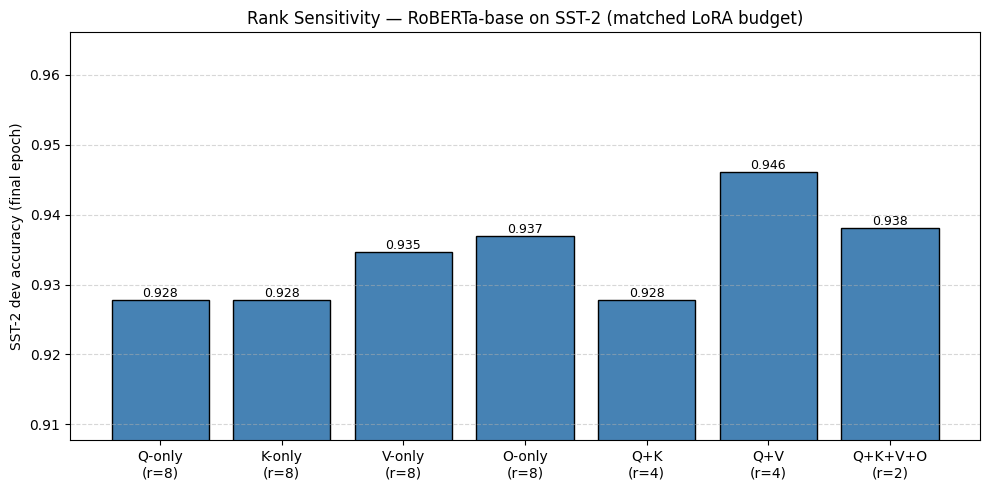

In [ ]:
import matplotlib.pyplot as plt


def _display_name_from_targets(targets):
    upper = [t.upper() for t in targets]
    if len(upper) == 1:
        return f"{upper[0]}-only"
    return "+".join(upper)


def _build_summary_from_disk(results_dir="results"):
    """Load most recent SST-2 rank-sweep result per LoRA-target combination."""
    by_targets = {}
    for p in sorted(Path(results_dir).glob("sst2__lora-*__*.json")):
        try:
            with p.open() as f:
                data = json.load(f)
        except (OSError, json.JSONDecodeError):
            continue
        accs = data.get("eval_accuracy_by_epoch") or []
        if not accs or data.get("lora_r") is None:
            continue
        targets = tuple(data["model_tag"].replace("lora-", "").split("-"))
        # Sorted glob iterates by filename which ends with timestamp,
        # so later writes overwrite earlier ones for the same target set.
        by_targets[targets] = {
            "name": _display_name_from_targets(targets),
            "targets": targets,
            "rank": data["lora_r"],
            "final_acc": accs[-1],
            "results_path": str(p),
        }
    return list(by_targets.values())


try:
    summary = list(rank_sweep_summary)
    if not summary:
        raise NameError("rank_sweep_summary is empty")
except NameError:
    summary = _build_summary_from_disk()
    print(f"Loaded {len(summary)} runs from disk.")

if not summary:
    raise RuntimeError(
        "No rank-sweep results found. Run the rank sensitivity sweep cell above first."
    )

# Order matches the picture: Q, K, V, O singles, then Q+K, Q+V, then Q+K+V+O
desired_order = ["Q-only", "K-only", "V-only", "O-only", "Q+K", "Q+V", "Q+K+V+O"]
summary_sorted = sorted(
    summary,
    key=lambda r: desired_order.index(r["name"]) if r["name"] in desired_order else 99,
)

names = [r["name"] for r in summary_sorted]
accs = [r["final_acc"] for r in summary_sorted]
ranks = [r["rank"] for r in summary_sorted]
labels = [f"{n}\n(r={k})" for n, k in zip(names, ranks)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, accs, color="steelblue", edgecolor="black")
ax.set_ylabel("SST-2 dev accuracy (final epoch)")
ax.set_title("Rank Sensitivity — RoBERTa-base on SST-2 (matched LoRA budget)")

ymin = max(0.0, min(accs) - 0.02)
ax.set_ylim(ymin, min(1.0, max(accs) + 0.02))
ax.grid(axis="y", linestyle="--", alpha=0.5)

for bar, v in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()

results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)
fig_path = results_dir / f"rank_sensitivity_bar_{datetime.now().strftime('%Y%m%d-%H%M%S')}.png"
fig.savefig(fig_path, dpi=150)
print(f"Saved bar chart to {fig_path}")

plt.show()

Saved fancy bar chart to results/rank_sensitivity_bar_fancy_20260430-065514.png


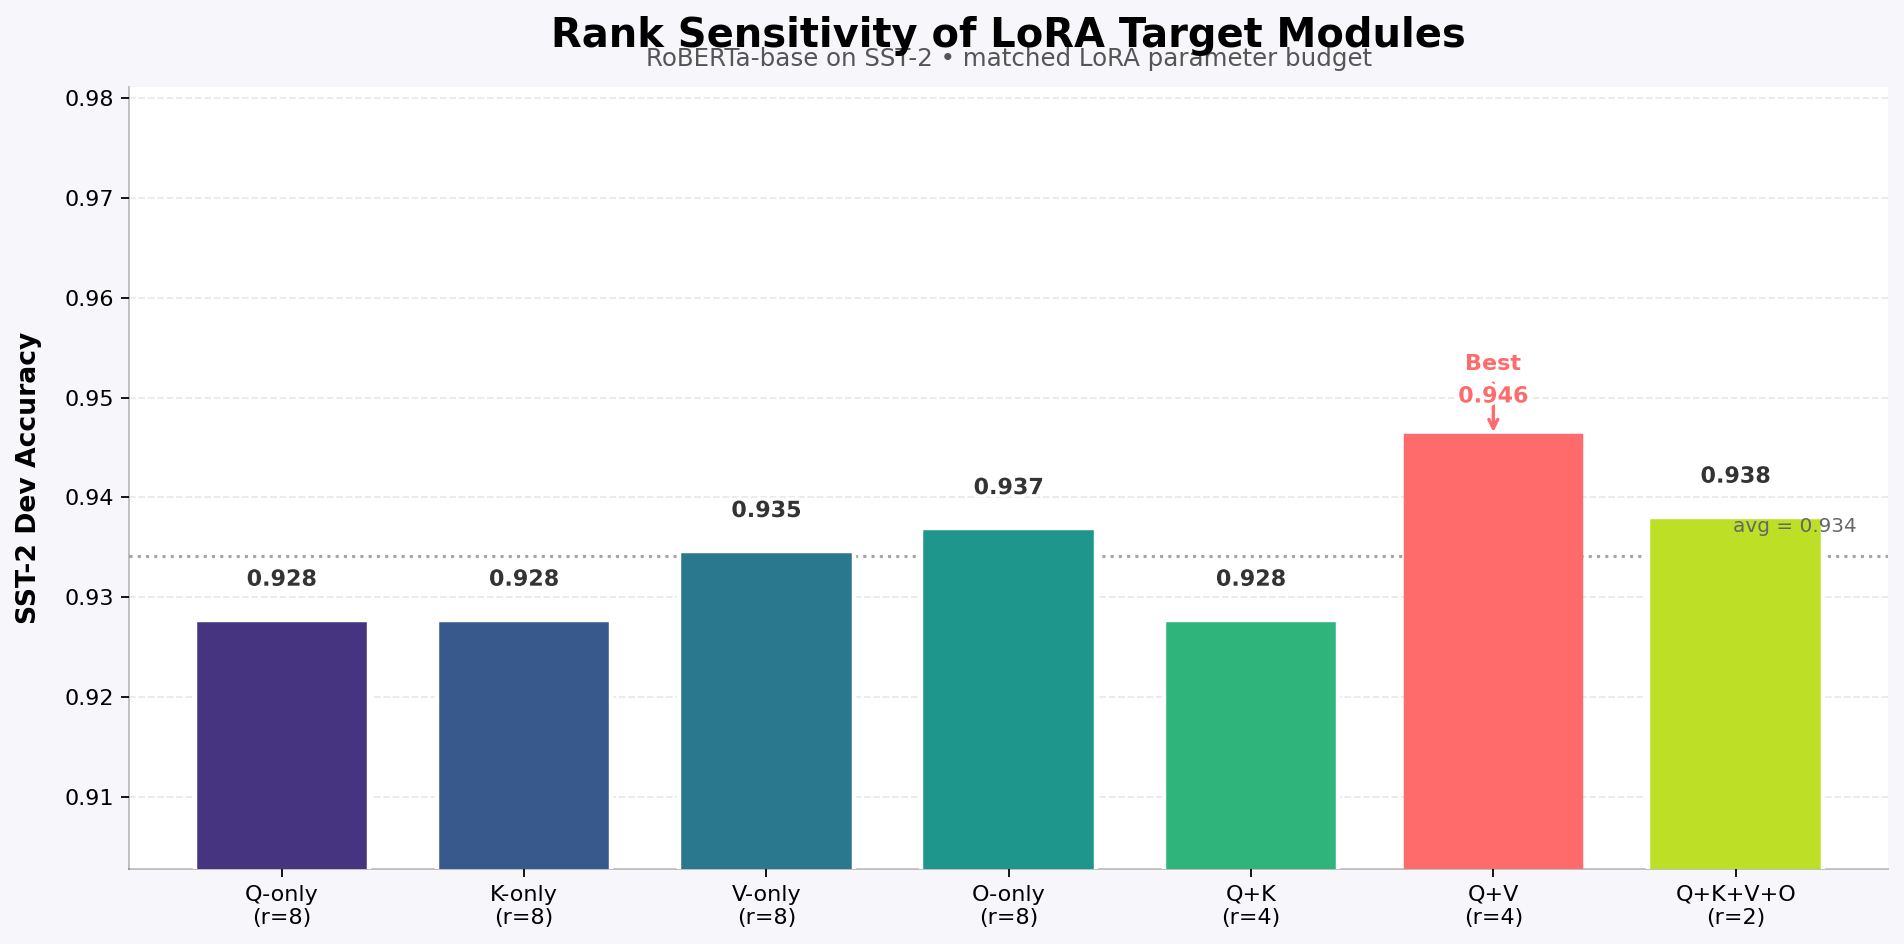

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patheffects
import matplotlib.colors as mcolors
from pathlib import Path
from datetime import datetime

# ---- Fancy plot ----

fig, ax = plt.subplots(figsize=(12, 6), dpi=160)

# Background
fig.patch.set_facecolor("#f7f7fb")
ax.set_facecolor("#ffffff")

x = np.arange(len(labels))

# Color palette (convert to list so we can modify it)
colors = list(plt.cm.viridis(np.linspace(0.15, 0.9, len(labels))))

# Highlight best accuracy
best_idx = int(np.argmax(accs))
colors[best_idx] = mcolors.to_rgba("#ff6b6b")

# Optional: highlight edge too
edgecolors = ["white"] * len(labels)
edgecolors[best_idx] = "#ff6b6b"

bars = ax.bar(
    x,
    accs,
    color=colors,
    edgecolor=edgecolors,
    linewidth=2.0,
    width=0.72,
    zorder=3,
)

# Y-axis range
ymin = max(0.0, min(accs) - 0.025)
ymax = min(1.0, max(accs) + 0.035)
ax.set_ylim(ymin, ymax)

# Titles
ax.set_title(
    "Rank Sensitivity of LoRA Target Modules",
    fontsize=18,
    fontweight="bold",
    pad=18,
)

ax.text(
    0.5,
    1.02,
    "RoBERTa-base on SST-2 • matched LoRA parameter budget",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color="#555555",
)

# Axis labels
ax.set_ylabel(
    "SST-2 Dev Accuracy",
    fontsize=12,
    fontweight="bold",
    labelpad=10,
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.28,
    zorder=0,
)

# Clean spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax.spines["left"].set_alpha(0.25)
ax.spines["bottom"].set_alpha(0.25)

# Value labels
for i, (bar, v) in enumerate(zip(bars, accs)):
    label_color = "#ff6b6b" if i == best_idx else "#333333"

    txt = ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.003,
        f"{v:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=label_color,
        zorder=4,
    )

    txt.set_path_effects([
        patheffects.withStroke(linewidth=3, foreground="white")
    ])

# Best annotation
best_bar = bars[best_idx]
best_acc = accs[best_idx]

ax.annotate(
    "Best",
    xy=(best_bar.get_x() + best_bar.get_width() / 2, best_acc),
    xytext=(0, 28),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=10,
    fontweight="bold",
    color="#ff6b6b",
    arrowprops=dict(
        arrowstyle="->",
        color="#ff6b6b",
        linewidth=1.5,
    ),
)

# Average line
avg_acc = sum(accs) / len(accs)
ax.axhline(
    avg_acc,
    color="#888888",
    linestyle=":",
    linewidth=1.4,
    alpha=0.75,
    zorder=2,
)

ax.text(
    len(labels) - 0.5,
    avg_acc + 0.002,
    f"avg = {avg_acc:.3f}",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#666666",
)

# Padding
ax.margins(x=0.04)

plt.tight_layout()

# Save
results_dir = Path("results")
results_dir.mkdir(parents=True, exist_ok=True)

fig_path = results_dir / f"rank_sensitivity_bar_fancy_{datetime.now().strftime('%Y%m%d-%H%M%S')}.png"
fig.savefig(fig_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())

print(f"Saved fancy bar chart to {fig_path}")

plt.show()